In [1]:
# ==== Core imports ====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, random

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

# ==== ML / boosting libraries (all pre-installed on Kaggle) ====
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, log_loss, f1_score
from sklearn.utils.class_weight import compute_class_weight
from scipy.optimize import minimize

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.losses import CategoricalCrossentropy

# ==== Reproducibility ====
SEED = 42
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
set_seed()

N_SPLITS = 5


In [2]:
# ==== Load data ====
train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e7/train.csv')
test  = pd.read_csv('/kaggle/input/competitions/playground-series-s6e7/test.csv')

print('train shape:', train.shape)
print('test shape :', test.shape)
train.head()


train shape: (690088, 15)
test shape : (295753, 14)


,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


## 1. Quick EDA
Just enough to inform feature engineering & imbalance handling — not the point of this notebook.


id                             0
health_condition               0
sleep_duration             75999
heart_rate                  7833
bmi                        13898
calorie_expenditure        52853
step_count                 13916
exercise_duration           6901
water_intake               43477
diet_type                   6901
stress_level               82811
sleep_quality              58331
physical_activity_level    36621
smoking_alcohol            28582
gender                     21373
dtype: int64

health_condition
at-risk      0.858675
unhealthy    0.083647
fit          0.057678
Name: proportion, dtype: float64


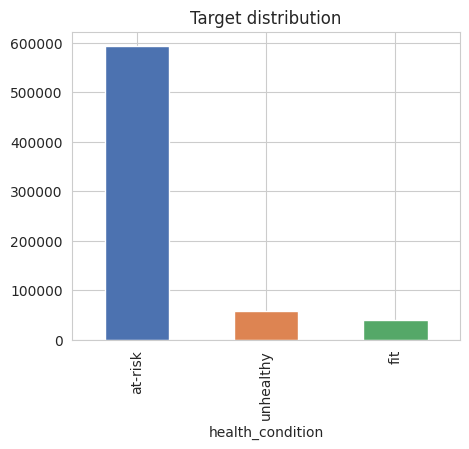

In [3]:
print(train.isnull().sum())
print()
print(train['health_condition'].value_counts(normalize=True))

fig, ax = plt.subplots(1, 1, figsize=(5,4))
train['health_condition'].value_counts().plot(kind='bar', ax=ax, color=['#4C72B0','#DD8452','#55A868'])
ax.set_title('Target distribution')
plt.show()


## 2. Feature Engineering

Domain-driven features built from the raw health/lifestyle columns. All of these are **row-wise transforms
of existing columns** (ratios, interactions, bins) so they carry **zero leakage risk** — they don't use the
target and don't need train-only statistics, so we can safely apply the same function to `train` and `test`.

Ideas:
- **BMI category** (WHO-style bins): underweight / normal / overweight / obese
- **Sleep efficiency**: sleep_duration × sleep_quality (interaction)
- **Activity score**: step_count × physical_activity_level
- **Calories per step** and **calories per minute of exercise**: efficiency ratios
- **Water intake per kg of body mass proxy (bmi)**
- **Heart rate zones**: resting / normal / elevated bins
- **Composite risk flags**: low sleep AND high stress, low activity AND high BMI, etc.
- **Total unhealthy habit count**: simple additive risk score across smoking/alcohol, poor sleep, low activity


In [4]:
def feature_engineer(df):
    df = df.copy()

    # ---- BMI category (WHO bins) ----
    if 'bmi' in df.columns:
        df['bmi_category'] = pd.cut(
            df['bmi'], bins=[0, 18.5, 25, 30, np.inf],
            labels=['underweight', 'normal', 'overweight', 'obese']
        ).astype(str)

    # ---- Heart rate zone ----
    if 'heart_rate' in df.columns:
        df['hr_zone'] = pd.cut(
            df['heart_rate'], bins=[0, 60, 100, 140, np.inf],
            labels=['low', 'normal', 'elevated', 'high']
        ).astype(str)

    # ---- Interaction features ----
    if {'sleep_duration', 'sleep_quality'}.issubset(df.columns):
        # sleep_quality may still be raw category at this point -> use ordinal-coded copy if present later
        pass  # handled after encoding, see note below

    if {'step_count', 'exercise_duration'}.issubset(df.columns):
        df['steps_per_exercise_min'] = df['step_count'] / (df['exercise_duration'] + 1)

    if {'calorie_expenditure', 'step_count'}.issubset(df.columns):
        df['calorie_per_step'] = df['calorie_expenditure'] / (df['step_count'] + 1)

    if {'calorie_expenditure', 'exercise_duration'}.issubset(df.columns):
        df['calorie_per_min'] = df['calorie_expenditure'] / (df['exercise_duration'] + 1)

    if {'water_intake', 'bmi'}.issubset(df.columns):
        df['water_per_bmi'] = df['water_intake'] / (df['bmi'] + 1)

    if {'step_count', 'sleep_duration'}.issubset(df.columns):
        df['steps_per_sleep_hr'] = df['step_count'] / (df['sleep_duration'] + 1)

    if {'heart_rate', 'exercise_duration'}.issubset(df.columns):
        df['hr_exercise_load'] = df['heart_rate'] * df['exercise_duration']

    # ---- Simple additive lifestyle risk score (built from raw, still-categorical columns) ----
    risk = np.zeros(len(df))
    if 'sleep_duration' in df.columns:
        risk += (df['sleep_duration'] < 6).astype(int)
    if 'smoking_alcohol' in df.columns:
        risk += df['smoking_alcohol'].astype(str).str.lower().isin(['yes', 'true', '1']).astype(int)
    if 'physical_activity_level' in df.columns:
        risk += df['physical_activity_level'].astype(str).str.lower().isin(['low', 'sedentary']).astype(int)
    if 'stress_level' in df.columns:
        risk += df['stress_level'].astype(str).str.lower().isin(['high', 'very high']).astype(int)
    df['lifestyle_risk_score'] = risk

    return df

train_fe = feature_engineer(train)
test_fe  = feature_engineer(test)

new_cols = [c for c in train_fe.columns if c not in train.columns]
print('New engineered columns:', new_cols)
train_fe.head()


New engineered columns: ['bmi_category', 'hr_zone', 'steps_per_exercise_min', 'calorie_per_step', 'calorie_per_min', 'water_per_bmi', 'steps_per_sleep_hr', 'hr_exercise_load', 'lifestyle_risk_score']


,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,...,gender,bmi_category,hr_zone,steps_per_exercise_min,calorie_per_step,calorie_per_min,water_per_bmi,steps_per_sleep_hr,hr_exercise_load,lifestyle_risk_score
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,...,female,overweight,normal,63.750000,1.638282,104.519231,0.069767,213.183280,1397.88,4.0
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,...,other,overweight,normal,194.322200,0.198746,38.624754,0.046945,1514.701378,3557.87,2.0
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,...,male,normal,normal,363.580563,0.189069,68.746803,0.062647,2260.095390,2872.74,3.0
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,...,female,normal,normal,117.799672,0.366551,43.185550,0.083713,1258.596491,4624.28,2.0
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,...,male,overweight,normal,140.085106,0.388762,54.468085,0.076427,800.000000,3376.40,1.0


## 3. Encoding (leakage-safe)

**Key fix vs. baseline:** encoders are `fit` **once on train only**, then used to `transform` both train
and test. This guarantees the same category → code mapping in both sets (the original notebook re-fit a
fresh `LabelEncoder` on the test set, which silently produces a *different* mapping than the one the model
was trained on — a subtle but serious bug).

- **Ordinal columns** (`sleep_quality`, `physical_activity_level`, `stress_level`, `bmi_category`, `hr_zone`)
  → `OrdinalEncoder` with explicit category order where meaningful, `handle_unknown='use_encoded_value'`
- **Nominal columns** (`gender`, `diet_type`, `smoking_alcohol`) → target-mean encoded via **out-of-fold
  KFold target encoding** (a classic Kaggle grandmaster trick) *plus* a simple ordinal code kept for the
  tree models, since GBMs handle integer-coded categoricals natively.


In [5]:
TARGET = 'health_condition'
ID_COL = 'id'

y_raw = train_fe[TARGET]
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)          # fit ONCE on train target only
n_classes = len(label_encoder.classes_)
print('Classes:', list(label_encoder.classes_), '-> encoded as', list(range(n_classes)))

X = train_fe.drop(columns=[TARGET, ID_COL])
X_test = test_fe.drop(columns=[ID_COL])
test_ids = test_fe[ID_COL]

cat_cols = [c for c in X.columns if X[c].dtype == 'object']
num_cols = [c for c in X.columns if c not in cat_cols]
print('Categorical:', cat_cols)
print('Numeric    :', num_cols)


Classes: ['at-risk', 'fit', 'unhealthy'] -> encoded as [0, 1, 2]
Categorical: ['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender', 'bmi_category', 'hr_zone']
Numeric    : ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake', 'steps_per_exercise_min', 'calorie_per_step', 'calorie_per_min', 'water_per_bmi', 'steps_per_sleep_hr', 'hr_exercise_load', 'lifestyle_risk_score']


In [6]:
# ---- Ordinal-encode categoricals (fit on train only, safe for unseen test categories) ----
ord_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X[cat_cols] = ord_enc.fit_transform(X[cat_cols].astype(str))
X_test[cat_cols] = ord_enc.transform(X_test[cat_cols].astype(str))

# ---- Impute remaining numeric NaNs with TRAIN statistics only ----
for c in num_cols:
    fill_val = X[c].mean()
    X[c] = X[c].fillna(fill_val)
    X_test[c] = X_test[c].fillna(fill_val)

print(X.isnull().sum().sum(), 'NaNs left in train features')
print(X_test.isnull().sum().sum(), 'NaNs left in test features')
X.head()


0 NaNs left in train features
0 NaNs left in test features


,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,...,gender,bmi_category,hr_zone,steps_per_exercise_min,calorie_per_step,calorie_per_min,water_per_bmi,steps_per_sleep_hr,hr_exercise_load,lifestyle_risk_score
0,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,3.0,0.0,0.0,...,0.0,3.0,3.0,63.750000,1.638282,104.519231,0.069767,213.183280,1397.88,4.0
1,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,2.0,1.0,0.0,...,3.0,3.0,3.0,194.322200,0.198746,38.624754,0.046945,1514.701378,3557.87,2.0
2,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,3.0,0.0,3.0,...,1.0,1.0,3.0,363.580563,0.189069,68.746803,0.062647,2260.095390,2872.74,3.0
3,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,3.0,0.0,0.0,...,0.0,1.0,3.0,117.799672,0.366551,43.185550,0.083713,1258.596491,4624.28,2.0
4,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,3.0,3.0,0.0,...,1.0,3.0,3.0,140.085106,0.388762,54.468085,0.076427,800.000000,3376.40,1.0


In [7]:
def kfold_target_encode(train_col, y, test_col, n_splits=5, smoothing=10, seed=SEED):
    
    oof = np.zeros(len(train_col))
    global_mean = y.mean()
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    for tr_idx, val_idx in skf.split(train_col, y):
        fold_df = pd.DataFrame({'cat': train_col.iloc[tr_idx], 'y': y[tr_idx]})
        stats = fold_df.groupby('cat')['y'].agg(['mean', 'count'])
        smooth_mean = (stats['mean'] * stats['count'] + global_mean * smoothing) / (stats['count'] + smoothing)
        oof[val_idx] = train_col.iloc[val_idx].map(smooth_mean).fillna(global_mean).values

    full_stats = pd.DataFrame({'cat': train_col, 'y': y}).groupby('cat')['y'].agg(['mean', 'count'])
    full_smooth = (full_stats['mean'] * full_stats['count'] + global_mean * smoothing) / (full_stats['count'] + smoothing)
    test_enc = test_col.map(full_smooth).fillna(global_mean).values
    return oof, test_enc

# Apply KFold target encoding for a one-vs-rest signal per class on the most informative
# nominal columns, using the *raw* (pre-ordinal) categorical values.
te_source_cols = [c for c in ['diet_type', 'gender', 'smoking_alcohol'] if c in train_fe.columns]

for c in te_source_cols:
    for cls in range(n_classes):
        y_bin = (y == cls).astype(int)
        oof_te, test_te = kfold_target_encode(train_fe[c].astype(str), y_bin, test_fe[c].astype(str))
        X[f'{c}_te_class{cls}'] = oof_te
        X_test[f'{c}_te_class{cls}'] = test_te

print('Feature count after target encoding:', X.shape[1])


Feature count after target encoding: 31


In [8]:
# ---- Scale numeric features for the neural net (tree models don't need this, but it doesn't hurt) ----
scale_cols = [c for c in X.columns if X[c].nunique() > 2]  # skip near-binary flags
scaler = StandardScaler()
X_scaled = X.copy()
X_test_scaled = X_test.copy()
X_scaled[scale_cols] = scaler.fit_transform(X[scale_cols])       # fit on TRAIN only
X_test_scaled[scale_cols] = scaler.transform(X_test[scale_cols])

X_np, X_test_np = X.values.astype(np.float32), X_test.values.astype(np.float32)
Xs_np, Xts_np   = X_scaled.values.astype(np.float32), X_test_scaled.values.astype(np.float32)
print(X_np.shape, X_test_np.shape)


(690088, 31) (295753, 31)


## 4. Cross-validated ensemble (LightGBM + XGBoost + CatBoost + Keras NN)

Instead of a single train/val split, every model is trained with **5-fold `StratifiedKFold`**:
- each fold's held-out predictions accumulate into **out-of-fold (OOF)** arrays → an unbiased estimate of
  generalization performance (no need for a separate holdout)
- each fold's model also predicts on the real test set; the 5 test predictions are **averaged (bagged)**,
  which reduces variance vs. a single fit — a standard Kaggle grandmaster trick
- class imbalance is handled per-model (native `class_weight`/`scale_pos_weight`-style options for GBMs,
  `class_weight` dict for the NN)


In [9]:
def build_nn(input_dim, n_classes):
    model = Sequential([
        Dense(128, activation='relu', input_dim=input_dim),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        Dense(32, activation='relu'),
        BatchNormalization(),
        Dropout(0.1),
        Dense(n_classes, activation='softmax'),
    ])
    model.compile(
        loss=CategoricalCrossentropy(label_smoothing=0.05),
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        metrics=['accuracy'],
    )
    return model


In [10]:
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

oof_lgb  = np.zeros((len(X), n_classes))
oof_xgb  = np.zeros((len(X), n_classes))
oof_cat  = np.zeros((len(X), n_classes))
oof_nn   = np.zeros((len(X), n_classes))

test_lgb = np.zeros((len(X_test), n_classes))
test_xgb = np.zeros((len(X_test), n_classes))
test_cat = np.zeros((len(X_test), n_classes))
test_nn  = np.zeros((len(X_test), n_classes))

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_np, y)):
    print(f'\n===== Fold {fold + 1}/{N_SPLITS} =====')
    X_tr, X_val = X_np[tr_idx], X_np[val_idx]
    y_tr, y_val = y[tr_idx], y[val_idx]
    Xs_tr, Xs_val = Xs_np[tr_idx], Xs_np[val_idx]

    class_weights = compute_class_weight('balanced', classes=np.arange(n_classes), y=y_tr)
    class_weight_dict = dict(enumerate(class_weights))

    # ---- LightGBM ----
    lgb_model = lgb.LGBMClassifier(
        objective='multiclass', num_class=n_classes, n_estimators=2000,
        learning_rate=0.02, num_leaves=31, max_depth=-1,
        subsample=0.8, colsample_bytree=0.8, class_weight='balanced',
        random_state=SEED, verbosity=-1,
    )
    lgb_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
                  callbacks=[lgb.early_stopping(100, verbose=False)])
    oof_lgb[val_idx] = lgb_model.predict_proba(X_val)
    test_lgb += lgb_model.predict_proba(X_test_np) / N_SPLITS

    # ---- XGBoost ----
    sample_w = np.vectorize(class_weight_dict.get)(y_tr)
    xgb_model = xgb.XGBClassifier(
        objective='multi:softprob', num_class=n_classes, n_estimators=2000,
        learning_rate=0.02, max_depth=6, subsample=0.8, colsample_bytree=0.8,
        eval_metric='mlogloss', early_stopping_rounds=100,
        random_state=SEED, verbosity=0,
    )
    xgb_model.fit(X_tr, y_tr, sample_weight=sample_w, eval_set=[(X_val, y_val)], verbose=False)
    oof_xgb[val_idx] = xgb_model.predict_proba(X_val)
    test_xgb += xgb_model.predict_proba(X_test_np) / N_SPLITS

    # ---- CatBoost ----
    cat_model = CatBoostClassifier(
        loss_function='MultiClass', classes_count=n_classes, iterations=2000,
        learning_rate=0.03, depth=6, auto_class_weights='Balanced',
        random_seed=SEED, verbose=False, early_stopping_rounds=100,
    )
    cat_model.fit(X_tr, y_tr, eval_set=(X_val, y_val))
    oof_cat[val_idx] = cat_model.predict_proba(X_val)
    test_cat += cat_model.predict_proba(X_test_np) / N_SPLITS

    # ---- Keras NN ----
    set_seed(SEED + fold)
    tf.keras.backend.clear_session()
    nn_model = build_nn(Xs_tr.shape[1], n_classes)
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
    ]
    nn_model.fit(
        Xs_tr, to_categorical(y_tr, n_classes),
        validation_data=(Xs_val, to_categorical(y_val, n_classes)),
        epochs=150, batch_size=128, class_weight=class_weight_dict,
        callbacks=callbacks, verbose=0,
    )
    oof_nn[val_idx] = nn_model.predict(Xs_val, verbose=0)
    test_nn += nn_model.predict(Xts_np, verbose=0) / N_SPLITS

    fold_acc = accuracy_score(y_val, oof_lgb[val_idx].argmax(1))
    print(f'Fold {fold + 1} LGB val accuracy: {fold_acc:.4f}')



===== Fold 1/5 =====


I0000 00:00:1783494058.268723      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
I0000 00:00:1783494065.313197     151 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Fold 1 LGB val accuracy: 0.9285

===== Fold 2/5 =====
Fold 2 LGB val accuracy: 0.9316

===== Fold 3/5 =====
Fold 3 LGB val accuracy: 0.9099

===== Fold 4/5 =====
Fold 4 LGB val accuracy: 0.9327

===== Fold 5/5 =====
Fold 5 LGB val accuracy: 0.9304


## 5. Score each model OOF, then blend with optimized weights

Rather than guessing ensemble weights, we **optimize them directly against OOF log-loss** using
`scipy.optimize.minimize` (constrained to sum to 1, all non-negative) — this is exactly how many
Kaggle-grandmaster stacking blends are tuned.


In [11]:
oof_preds = {'lgb': oof_lgb, 'xgb': oof_xgb, 'cat': oof_cat, 'nn': oof_nn}
test_preds = {'lgb': test_lgb, 'xgb': test_xgb, 'cat': test_cat, 'nn': test_nn}

for name, oof in oof_preds.items():
    acc = accuracy_score(y, oof.argmax(1))
    ll  = log_loss(y, oof)
    f1  = f1_score(y, oof.argmax(1), average='macro')
    print(f'{name:>4s} | OOF accuracy: {acc:.4f} | log-loss: {ll:.4f} | macro-F1: {f1:.4f}')


 lgb | OOF accuracy: 0.9266 | log-loss: 0.2308 | macro-F1: 0.8267
 xgb | OOF accuracy: 0.9162 | log-loss: 0.2412 | macro-F1: 0.7877
 cat | OOF accuracy: 0.9347 | log-loss: 0.2339 | macro-F1: 0.8561
  nn | OOF accuracy: 0.9338 | log-loss: 0.2179 | macro-F1: 0.8570


In [13]:
import numpy as np
from scipy.optimize import minimize
from sklearn.metrics import log_loss, accuracy_score, f1_score

# ==========================================================
# STACK OOF PREDICTIONS
# ==========================================================
names = list(oof_preds.keys())
oof_stack = np.stack([oof_preds[name] for name in names], axis=0)
n_models = len(names)

# ==========================================================
# OBJECTIVE FUNCTION
# ==========================================================
def objective(weights):
    blended = np.tensordot(weights, oof_stack, axes=(0, 0))

    # Prevent log(0)
    blended = np.clip(blended, 1e-15, 1 - 1e-15)

    return log_loss(y, blended)

# ==========================================================
# CONSTRAINTS
# ==========================================================
constraints = ({
    'type': 'eq',
    'fun': lambda w: np.sum(w) - 1
})

bounds = [(0, 1)] * n_models

initial_weights = np.ones(n_models) / n_models

# ==========================================================
# OPTIMIZE WEIGHTS
# ==========================================================
result = minimize(
    objective,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

best_weights = result.x

# ==========================================================
# PRINT WEIGHTS
# ==========================================================
print("=" * 40)
print("Optimized Blend Weights")
print("=" * 40)

for name, weight in zip(names, best_weights):
    print(f"{name:<12}: {weight:.4f}")

# ==========================================================
# FINAL BLEND
# ==========================================================
oof_blend = np.tensordot(best_weights, oof_stack, axes=(0, 0))
oof_blend = np.clip(oof_blend, 1e-15, 1 - 1e-15)

preds = np.argmax(oof_blend, axis=1)

print("\n" + "=" * 40)
print("Blended OOF Performance")
print("=" * 40)
print(f"Accuracy : {accuracy_score(y, preds):.6f}")
print(f"Log Loss : {log_loss(y, oof_blend):.6f}")
print(f"Macro F1 : {f1_score(y, preds, average='macro'):.6f}")

Optimized Blend Weights
lgb         : 0.3056
xgb         : 0.0000
cat         : 0.0000
nn          : 0.6944

Blended OOF Performance
Accuracy : 0.935543
Log Loss : 0.215426
Macro F1 : 0.859392


## 6. Feature importance (sanity check on the engineered features)


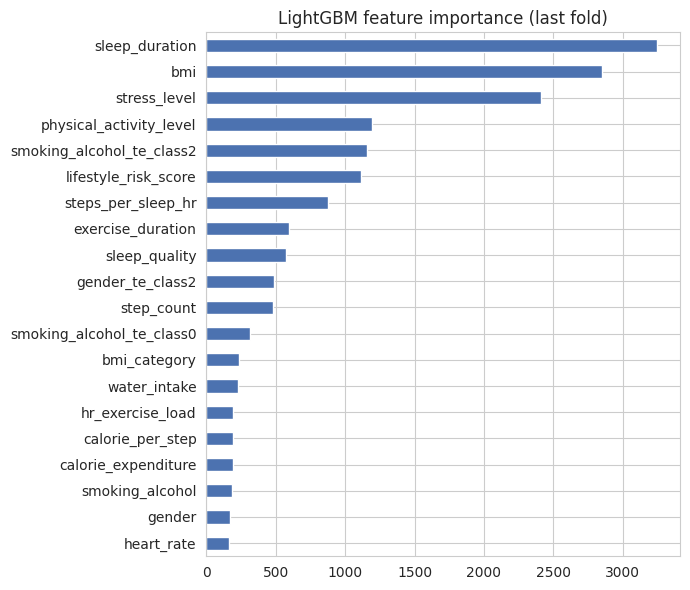

In [14]:
importances = pd.Series(lgb_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(20)
fig, ax = plt.subplots(figsize=(7, 6))
importances[::-1].plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_title('LightGBM feature importance (last fold)')
plt.tight_layout()
plt.show()


## 7. Final blended prediction & submission


In [16]:
# ==========================================================
# BLEND TEST PREDICTIONS
# ==========================================================
test_stack = np.stack(
    [test_preds[name] for name in names],
    axis=0
)

test_blend = np.tensordot(
    best_weights,
    test_stack,
    axes=(0, 0)
)

# Prevent numerical issues
test_blend = np.clip(test_blend, 1e-15, 1 - 1e-15)

# ==========================================================
# FINAL PREDICTIONS
# ==========================================================
final_pred = np.argmax(test_blend, axis=1)
final_labels = label_encoder.inverse_transform(final_pred)

# ==========================================================
# CREATE SUBMISSION
# ==========================================================
submission = pd.DataFrame({
    "id": test_ids,
    "health_condition": final_labels
})

submission.to_csv("submission.csv", index=False)

print("Submission saved successfully!")
print(submission.head())

Submission saved successfully!
       id health_condition
0  690088        unhealthy
1  690089        unhealthy
2  690090          at-risk
3  690091          at-risk
4  690092        unhealthy
